In this file I will implement two Random Forest classifiers, SHAP explanations and a system to connect the SHAP explanations to past event sthrough the comparmental models in MathematicalModel.ipynb  ...

Import statements:

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve,roc_auc_score,classification_report)
import shap
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import classification_report, roc_curve
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


C:\Users\emmxc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Data obtained from the mathematical models

preprocessed = "C:/Users/emmxc/OneDrive/Escritorio/thesis/FinalProjectThesis/MachineLearning/kinetics.csv"
df = pd.read_csv(preprocessed, sep="\t")

print("Hyperglycemia positives:", df['Hyperglycemia'].sum())
print("Hyperglycemia negatives:", (df['Hyperglycemia'] == 0).sum())

print("Hypoglycemia positives:", df['Hypoglycemia'].sum())
print("Hypoglycemia negatives:", (df['Hypoglycemia'] == 0).sum())

df_original = df.copy()


Hyperglycemia positives: 1599
Hyperglycemia negatives: 1089
Hypoglycemia positives: 126
Hypoglycemia negatives: 2562


For the machine learning classifier I implement Random Forest. Writing this towards the end I regret not trying XBoost too because it could have brought better results, but the focus is not to improve the model's accuracy but to obtain good event explanations from it:

We want the input of the model to be the attribute of each feature per time step for the last 2 hours t-15,t-30 etc etc. And the output columns of hyperglycemia or hypoglycemia.

Parameters setup:

It focuses on these features: 'Glucose', 'BPM' (heart rate), 'Distance', 'Calories', 'Insulin on board', 'COB' (Carbs On Board).

Uses a window size of 8 time points (each time point represents 15 minutes, so 8 x 15 = 2 hours).

It tries to predict 15 minutes ahead (step_ahead = 1).

The target is whether hyperglycemia will happen (Glucose > 6.9 mmol/L).

By build window dataset we mean to build a 2 hour prior window, since that is the data we want to use to train and predict, not the whole dataset.

In [3]:
def build_windowed_dataset(df, prediction_horizon, window_minutes=120, interval_minutes=15):
 
    features = ['Glucose', 'BPM', 'Distance', 'Calories', 'Insulin on board', 'COB']
    step_ahead = prediction_horizon // interval_minutes
    window_size = window_minutes // interval_minutes

    df = df.sort_values('Time').reset_index(drop=False)
    df['Glucose_future'] = df['Glucose'].shift(-step_ahead)
    df['Hyperglycemia'] = (df['Glucose_future'] > 6.9).astype(int)
    df['Hypoglycemia'] = (df['Glucose_future'] < 3.9).astype(int)

    X_rows = []
    y_hyper = []
    y_hypo = []
    times = []

    for i in range(len(df) - step_ahead):
        start_idx = max(0, i - window_size + 1)
        window_df = df.iloc[start_idx:i+1][features]

 
        if len(window_df) < window_size:
            padding = pd.DataFrame(np.nan, index=range(window_size - len(window_df)), columns=features)
            window_df = pd.concat([padding, window_df], ignore_index=True)

        # Skip windows with NaNs
        if window_df.isnull().values.any():
            continue

        X_rows.append(window_df.values.flatten())
        y_hyper.append(df.iloc[i + step_ahead]['Hyperglycemia'])
        y_hypo.append(df.iloc[i + step_ahead]['Hypoglycemia'])

    # Create column names
    col_names = []
    for lag in range(window_size):
        time_offset = (window_size - lag - 1) * interval_minutes  
        for feat in features:
            col_names.append(f"{feat}_t-{time_offset}min")

    df_windows = pd.DataFrame(X_rows, columns=col_names)
    df_windows['Outcome_Hyperglycemia'] = y_hyper
    df_windows['Outcome_Hypoglycemia'] = y_hypo

    return df_windows




Now we do dfs for the different prediction horizons since we want to see how the prediction changes for each of them and which is the best trade-off between clinical importance and good performance

In [4]:
prediction_horizons = [15, 30, 60, 120]  # in minutes

dfs = {}
for horizon in prediction_horizons:
    dftemp = build_windowed_dataset(df,horizon)
    dfs[horizon] = dftemp



    

In [5]:
data_splits = {}

for horizon in prediction_horizons:
    df_combined = build_windowed_dataset(df, horizon)

    X = df_combined.drop(columns=['Outcome_Hyperglycemia', 'Outcome_Hypoglycemia'])
    y_hyper = df_combined['Outcome_Hyperglycemia']
    y_hypo = df_combined['Outcome_Hypoglycemia']

    # Split once using hyperglycemia labels and stratify on it 
    X_train, X_test, y_hyper_train, y_hyper_test, y_hypo_train, y_hypo_test = train_test_split(
        X, y_hyper, y_hypo, test_size=0.3, random_state=42, stratify=y_hypo
    )

    # Save splits for this horizon
    data_splits[horizon] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_hyper_train': y_hyper_train,
        'y_hyper_test': y_hyper_test,
        'y_hypo_train': y_hypo_train,
        'y_hypo_test': y_hypo_test
    }

The next method is to print the misclassifications in order to find them easier when evaluating explanations, it is just for experimental purposes

In [6]:
def error_cases_analysis(X_test, y_test, y_pred):
    import pandas as pd
    errors = pd.DataFrame(X_test).copy()
    errors['TrueLabel'] = y_test
    errors['Predicted'] = y_pred

    false_negatives = errors[(errors['TrueLabel'] == 1) & (errors['Predicted'] == 0)]
    false_positives = errors[(errors['TrueLabel'] == 0) & (errors['Predicted'] == 1)]
    true_positives = errors[(errors['TrueLabel'] == 1) & (errors['Predicted'] == 1)]
    true_negatives = errors[(errors['TrueLabel'] == 0) & (errors['Predicted'] == 0)]

    print(f"Number of false negatives: {len(false_negatives)}")
    print(f"Number of false positives: {len(false_positives)}")
    print(f"Number of true positives: {len(true_positives)}")
    print(f"Number of true negatives: {len(true_negatives)}")
    
    print("\nExample false negatives:\n", false_negatives.head())
    print("\nExample false positives:\n", false_positives.head())
    print("\nExample true positives:\n", true_positives.head())
    print("\nExample true negatives:\n", true_negatives.head())

def analyze_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"Confusion matrix:\n{cm}")
    print(f"True Negatives: {tn}, False Positives: {fp}")
    print(f"False Negatives: {fn}, True Positives: {tp}")


def plot_confusion_matrix(y_test, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

Now we make the method to train the RF for hyperglycemia

In [7]:
def train_hyperglycemia(prediction_horizon,df):

    #Get the data splits from before
    X_train = data_splits[prediction_horizon]['X_train']
    X_test = data_splits[prediction_horizon]['X_test']
    y_train =data_splits[prediction_horizon]['y_hyper_train']
    y_test =  data_splits[prediction_horizon]['y_hyper_test']

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)    

   
    y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of positive class (hyperglycemia)

    thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
    best_f1 = 0
    best_thresh = 0.5 

    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"Cutoff {thresh}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh


    # Convert probabilities to binary predictions using 0.5 cutoff
    y_pred = (y_proba >= best_thresh).astype(int)


    # Evaluate model
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix for Hyperglycemia Prediction")


    print("\nROC AUC Score:")
    print(roc_auc_score(y_test, y_proba))

    error_cases_analysis(X_test,y_test,y_pred)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    return rf




In [8]:

def plot_multiple_roc_curves(y_tests, y_probas, horizons):


    plt.figure(figsize=(8,6))
    for y_test, y_proba, horizon in zip(y_tests, y_probas, horizons):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'Horizon {horizon} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Different Prediction Horizons')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()




Lets now test it for multiple prediciton horizons

Cutoff 0.1: Precision=0.770, Recall=1.000, F1=0.870
Cutoff 0.3: Precision=0.850, Recall=0.980, F1=0.910
Cutoff 0.5: Precision=0.924, Recall=0.924, F1=0.924
Cutoff 0.7: Precision=0.951, Recall=0.820, F1=0.881
Cutoff 0.9: Precision=0.991, Recall=0.472, F1=0.639
Confusion Matrix:
[[258   2]
 [235 210]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.99      0.69       260
           1       0.99      0.47      0.64       445

    accuracy                           0.66       705
   macro avg       0.76      0.73      0.66       705
weighted avg       0.82      0.66      0.66       705



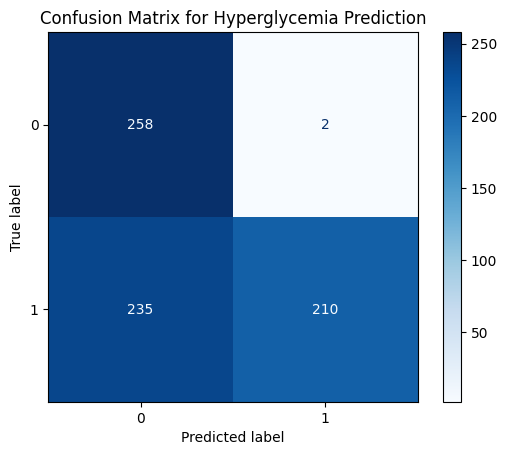


ROC AUC Score:
0.9583535004321521
Number of false negatives: 235
Number of false positives: 2
Number of true positives: 210
Number of true negatives: 258

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
1295               6.7     64.056450              271.6              19.36   
942               12.6     88.686561               20.8              22.26   
1805               6.5     83.193254              126.5              17.86   
293                6.9     71.003492              145.0              63.65   
680                9.1     75.962614              110.9              17.86   

      Insulin on board_t-105min  COB_t-105min  Glucose_t-90min  BPM_t-90min  \
1295                  16.489921      6.399704              6.8    62.021270   
942                   15.142193     20.540582             11.6    85.799259   
1805                  17.768657      4.046356              6.7    78.212963   
293                   17.889628  

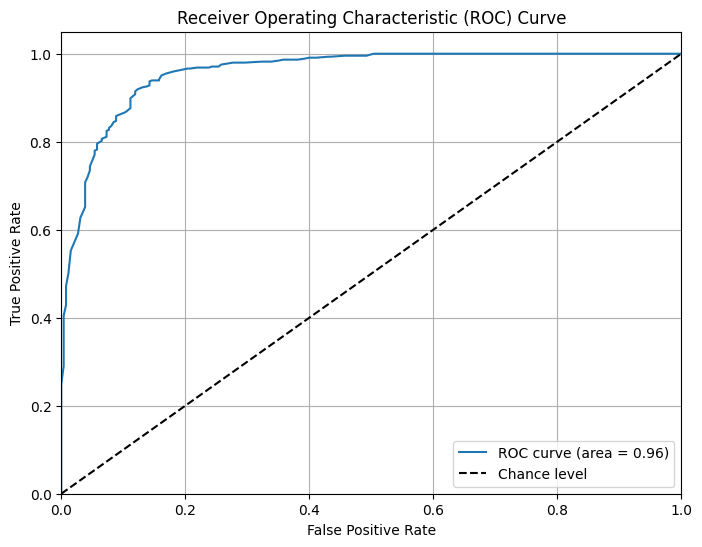

Cutoff 0.1: Precision=0.767, Recall=1.000, F1=0.868
Cutoff 0.3: Precision=0.805, Recall=0.991, F1=0.889
Cutoff 0.5: Precision=0.873, Recall=0.916, F1=0.894
Cutoff 0.7: Precision=0.935, Recall=0.703, F1=0.803
Cutoff 0.9: Precision=0.974, Recall=0.253, F1=0.401
Confusion Matrix:
[[251   3]
 [337 114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.99      0.60       254
           1       0.97      0.25      0.40       451

    accuracy                           0.52       705
   macro avg       0.70      0.62      0.50       705
weighted avg       0.78      0.52      0.47       705



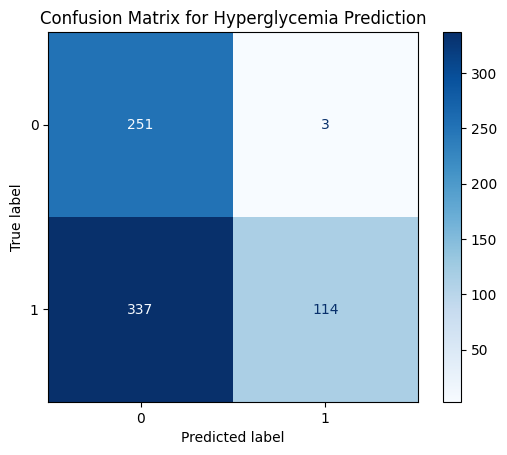


ROC AUC Score:
0.9254456413569147
Number of false negatives: 337
Number of false positives: 3
Number of true positives: 114
Number of true negatives: 251

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
593                3.4     57.659079                4.8              16.52   
1016               5.4     75.481407               90.0              70.33   
1488               6.3     62.543757               40.8              37.48   
189                4.3     81.807568                0.0              17.49   
1816               7.8     83.386946               21.5              17.64   

      Insulin on board_t-105min  COB_t-105min  Glucose_t-90min  BPM_t-90min  \
593                   21.840652  4.030506e-06              3.4    59.131852   
1016                  17.107854  6.669365e+00              5.4    76.160236   
1488                  17.994738  5.762543e+00              6.6    72.852239   
189                   16.669177  

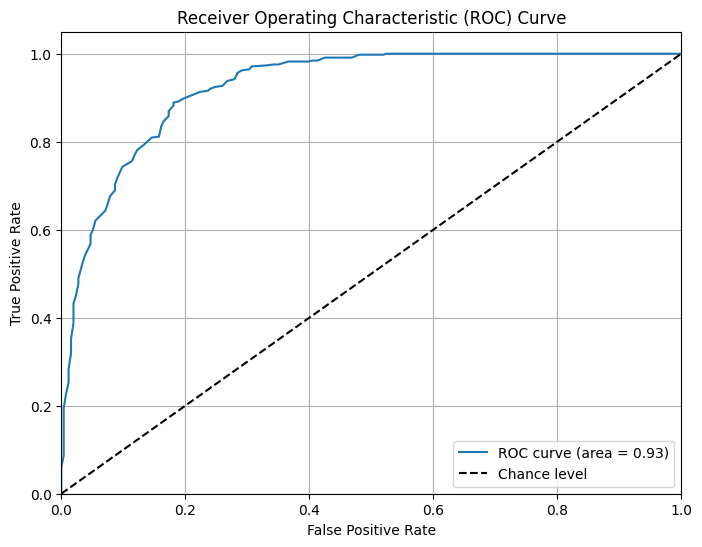

Cutoff 0.1: Precision=0.687, Recall=0.998, F1=0.814
Cutoff 0.3: Precision=0.741, Recall=0.986, F1=0.846
Cutoff 0.5: Precision=0.826, Recall=0.959, F1=0.887
Cutoff 0.7: Precision=0.889, Recall=0.718, F1=0.794
Cutoff 0.9: Precision=0.923, Recall=0.165, F1=0.280
Confusion Matrix:
[[262   6]
 [364  72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.98      0.59       268
           1       0.92      0.17      0.28       436

    accuracy                           0.47       704
   macro avg       0.67      0.57      0.43       704
weighted avg       0.73      0.47      0.40       704



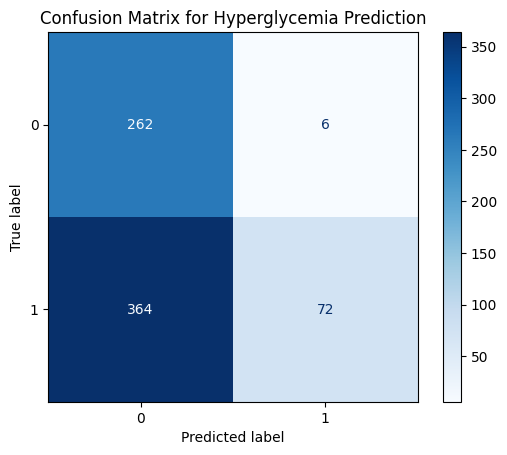


ROC AUC Score:
0.8841571956730111
Number of false negatives: 364
Number of false positives: 6
Number of true positives: 72
Number of true negatives: 262

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
613                6.5     74.555770                5.5              76.47   
375                6.6     78.413598              107.6              19.45   
2302               8.4     76.985556              312.5              86.04   
1974               7.4     72.884048                0.0              16.30   
1035              13.8     77.581481               45.7              19.05   

      Insulin on board_t-105min  COB_t-105min  Glucose_t-90min  BPM_t-90min  \
613                   21.312735      0.180123              6.5    70.922011   
375                   16.166664      8.777762              6.8    77.539690   
2302                  23.546529      5.625000              8.5    77.734656   
1974                  21.625673   

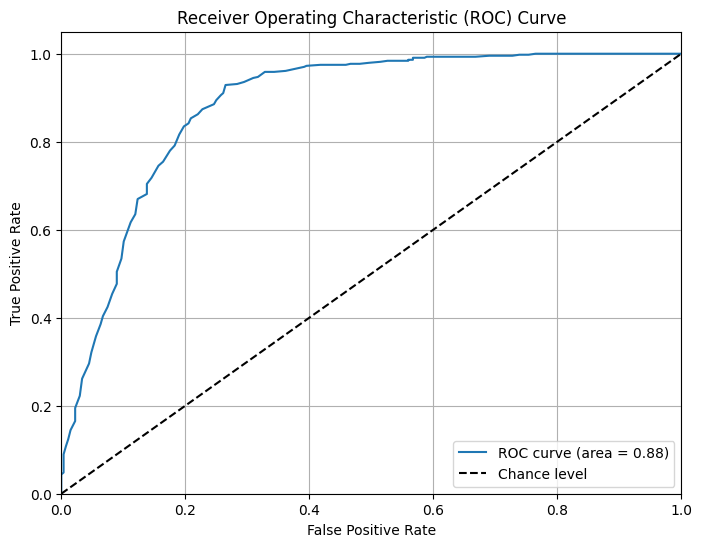

Cutoff 0.1: Precision=0.653, Recall=0.998, F1=0.790
Cutoff 0.3: Precision=0.720, Recall=0.987, F1=0.833
Cutoff 0.5: Precision=0.792, Recall=0.924, F1=0.853
Cutoff 0.7: Precision=0.893, Recall=0.581, F1=0.704
Cutoff 0.9: Precision=1.000, Recall=0.049, F1=0.094
Confusion Matrix:
[[257   0]
 [424  22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      1.00      0.55       257
           1       1.00      0.05      0.09       446

    accuracy                           0.40       703
   macro avg       0.69      0.52      0.32       703
weighted avg       0.77      0.40      0.26       703



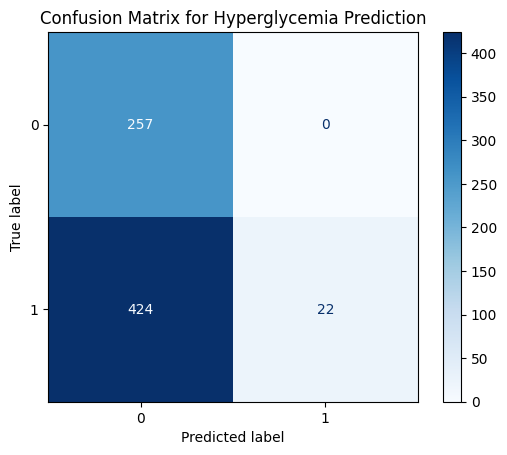


ROC AUC Score:
0.8567116260403762
Number of false negatives: 424
Number of false positives: 0
Number of true positives: 22
Number of true negatives: 257

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
4                  9.1     62.778730                0.0              21.17   
864               16.0     90.310269                0.0              28.65   
701                6.8     67.549101              577.9              19.91   
1511               8.2     51.512063               11.8              27.02   
543               12.4     68.973280                8.3              81.00   

      Insulin on board_t-105min  COB_t-105min  Glucose_t-90min  BPM_t-90min  \
4                      0.000000      0.000000              9.3    65.232937   
864                   11.283029      0.729234             15.6    91.413624   
701                   18.193675      0.128749              6.4    62.580045   
1511                  18.124174   

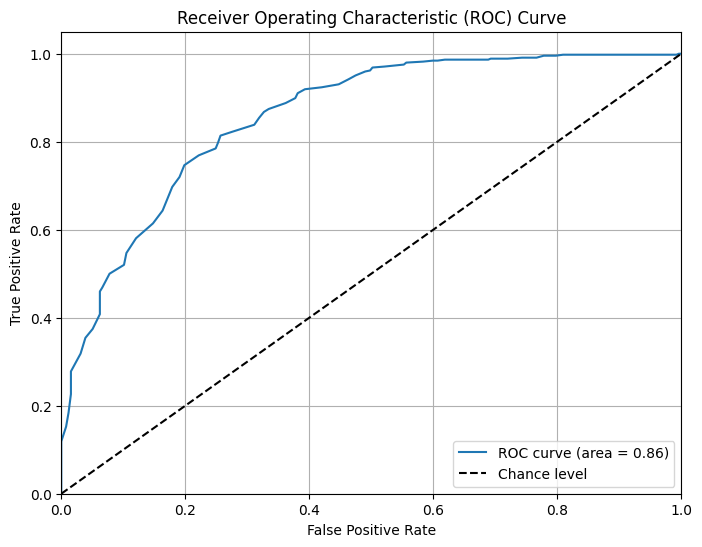

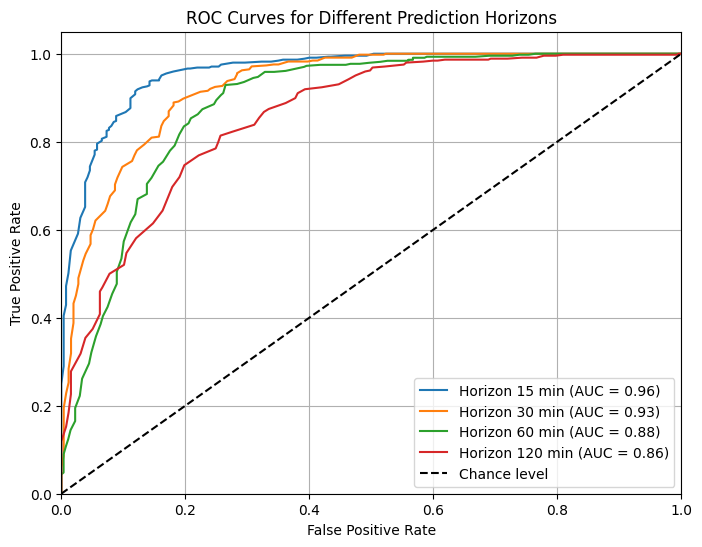

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
models = {}
y_tests = []
y_probas = []

for horizon in prediction_horizons:

    model = train_hyperglycemia(horizon, dfs[horizon])
    models[horizon] = model
    
    # Extract test data for this horizon 
    X_test = data_splits[horizon]['X_test']
    y_test = data_splits[horizon]['y_hyper_test']
    
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Append to lists
    y_tests.append(y_test)
    y_probas.append(y_proba)

# Plot ROC curves for all horizons
plot_multiple_roc_curves(y_tests, y_probas, horizons=[f"{h} min" for h in prediction_horizons])





Now we make the method to train the RF for hypoglycemia... same thing as hyper but with weights and different threshold

In [10]:
def train_hypo(prediction_horizon,df):


    X_train = data_splits[prediction_horizon]['X_train']
    X_test = data_splits[prediction_horizon]['X_test']
    y_train =data_splits[prediction_horizon]['y_hypo_train']
    y_test =  data_splits[prediction_horizon]['y_hypo_test']

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)    

    y_proba = rf.predict_proba(X_test)[:, 1]

    thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
    best_f1 = 0
    best_thresh = 0.5  # default

    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"Cutoff {thresh}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

    y_pred = (y_proba >= best_thresh).astype(int)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix for Hypoglycemia Prediction")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nROC AUC Score:")
    print(roc_auc_score(y_test, y_proba))

    error_cases_analysis(X_test,y_test,y_pred)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    return rf



Now we experiment for different prediction horizons

Cutoff 0.1: Precision=0.516, Recall=0.889, F1=0.653
Cutoff 0.3: Precision=0.707, Recall=0.806, F1=0.753
Cutoff 0.5: Precision=0.757, Recall=0.778, F1=0.767
Cutoff 0.7: Precision=0.800, Recall=0.667, F1=0.727
Cutoff 0.9: Precision=0.923, Recall=0.333, F1=0.490
Confusion Matrix:
[[668   1]
 [ 24  12]]


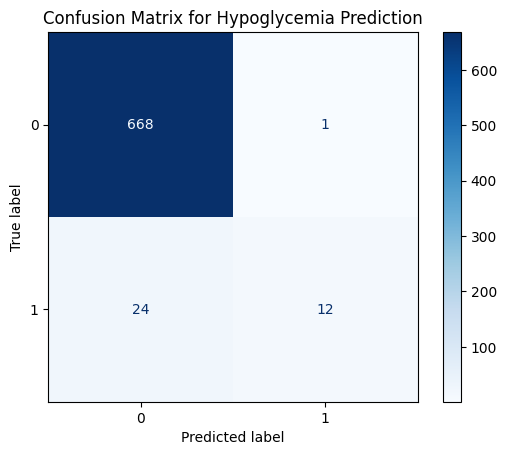


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       669
           1       0.92      0.33      0.49        36

    accuracy                           0.96       705
   macro avg       0.94      0.67      0.74       705
weighted avg       0.96      0.96      0.96       705


ROC AUC Score:
0.950921773791729
Number of false negatives: 24
Number of false positives: 1
Number of true positives: 12
Number of true negatives: 668

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
1762               5.2     56.490556                0.0              16.20   
93                 3.7     54.712011                0.0              16.83   
587                3.7     57.020397                0.0              17.92   
306               12.2    101.136003              298.7              71.51   
581                4.7     53.528333                0.0              16.30   

 

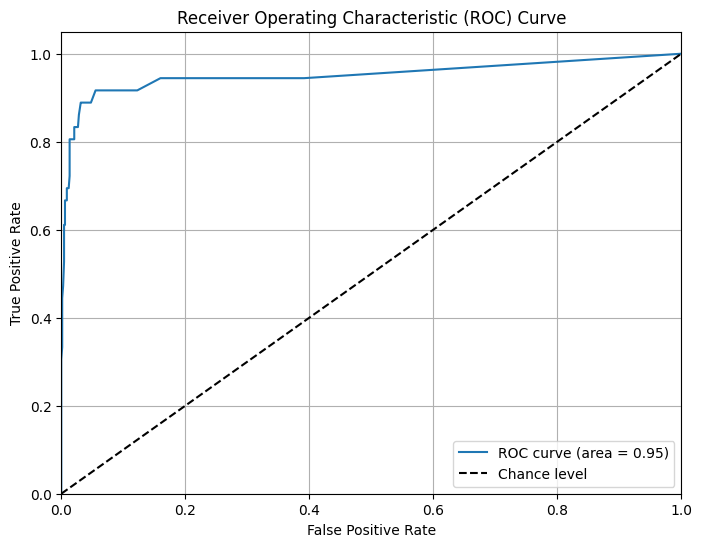

Cutoff 0.1: Precision=0.577, Recall=0.857, F1=0.690
Cutoff 0.3: Precision=0.718, Recall=0.800, F1=0.757
Cutoff 0.5: Precision=0.818, Recall=0.771, F1=0.794
Cutoff 0.7: Precision=0.857, Recall=0.514, F1=0.643
Cutoff 0.9: Precision=0.667, Recall=0.057, F1=0.105
Confusion Matrix:
[[669   1]
 [ 33   2]]


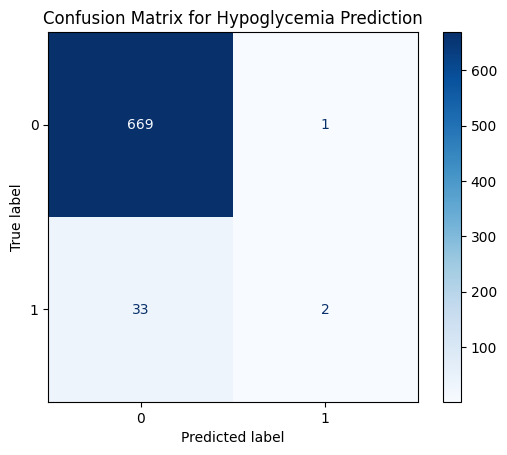


Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       670
           1       0.67      0.06      0.11        35

    accuracy                           0.95       705
   macro avg       0.81      0.53      0.54       705
weighted avg       0.94      0.95      0.93       705


ROC AUC Score:
0.9745202558635395
Number of false negatives: 33
Number of false positives: 1
Number of true positives: 2
Number of true negatives: 669

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
1702              12.0     87.151426                0.0               16.4   
1893               5.6     74.547196                0.0               16.9   
2122               4.2     57.026287                0.0               16.3   
582                4.4     55.846164                0.0               16.2   
2120               4.3     57.287922                0.0               16.2   

 

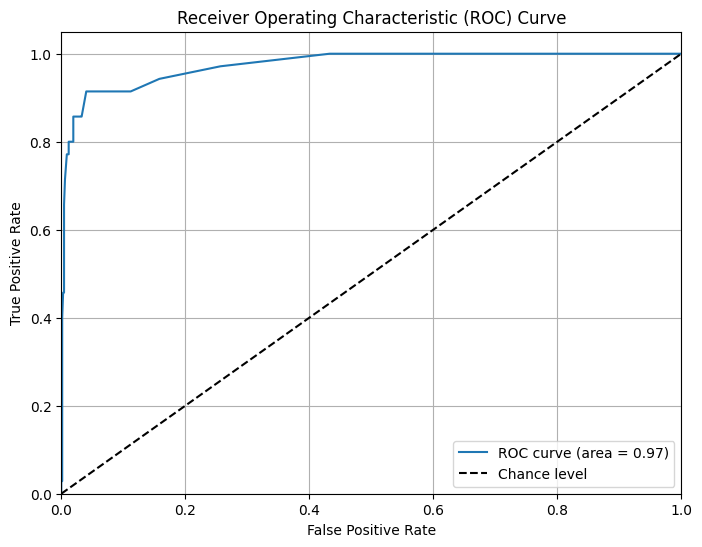

Cutoff 0.1: Precision=0.612, Recall=0.938, F1=0.741
Cutoff 0.3: Precision=0.963, Recall=0.812, F1=0.881
Cutoff 0.5: Precision=1.000, Recall=0.438, F1=0.609
Cutoff 0.7: Precision=1.000, Recall=0.344, F1=0.512
Cutoff 0.9: Precision=1.000, Recall=0.031, F1=0.061
Confusion Matrix:
[[672   0]
 [ 31   1]]


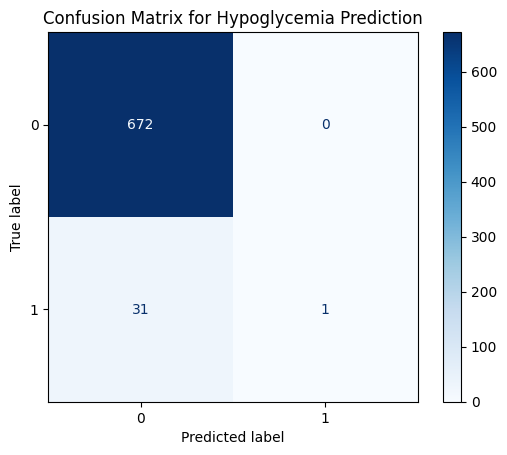


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       672
           1       1.00      0.03      0.06        32

    accuracy                           0.96       704
   macro avg       0.98      0.52      0.52       704
weighted avg       0.96      0.96      0.94       704


ROC AUC Score:
0.9840727306547619
Number of false negatives: 31
Number of false positives: 0
Number of true positives: 1
Number of true negatives: 672

Example false negatives:
      Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
161               4.3     52.327460                0.0              16.30   
720               6.8     56.560541                0.0              16.40   
575               6.4     54.555582                0.0              16.20   
488               4.1     54.904603                0.0              16.20   
483               4.8     54.718911                0.0              16.41   

     In

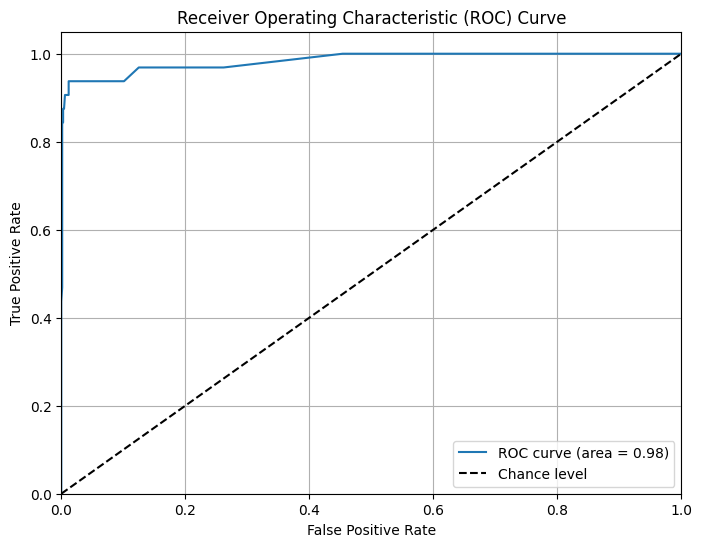

Cutoff 0.1: Precision=0.364, Recall=0.889, F1=0.516
Cutoff 0.3: Precision=0.778, Recall=0.519, F1=0.622
Cutoff 0.5: Precision=1.000, Recall=0.296, F1=0.457
Cutoff 0.7: Precision=1.000, Recall=0.111, F1=0.200
Cutoff 0.9: Precision=0.000, Recall=0.000, F1=0.000
Confusion Matrix:
[[676   0]
 [ 19   8]]


C:\Users\emmxc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


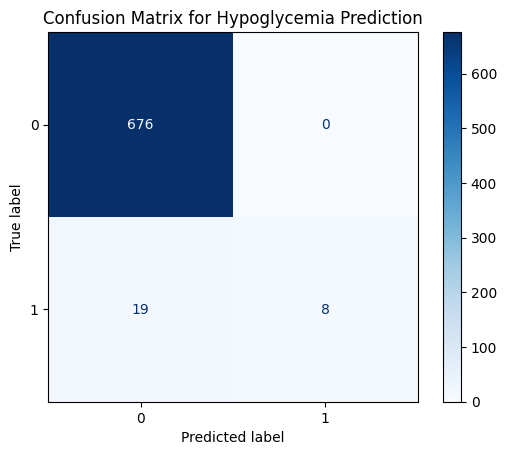


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       676
           1       1.00      0.30      0.46        27

    accuracy                           0.97       703
   macro avg       0.99      0.65      0.72       703
weighted avg       0.97      0.97      0.97       703


ROC AUC Score:
0.9439787420556651
Number of false negatives: 19
Number of false positives: 0
Number of true positives: 8
Number of true negatives: 676

Example false negatives:
       Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
2152              12.7     66.734578               30.2              33.72   
2117               6.1     55.581534                0.0              16.30   
1524               9.4     51.667674                0.0              16.62   
572                7.8     52.816284                4.8              16.20   
483                4.8     54.718911                0.0              16.41   

 

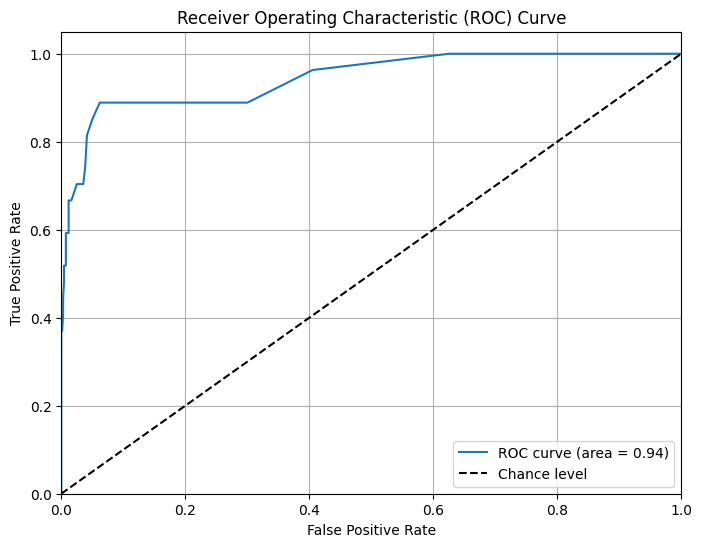

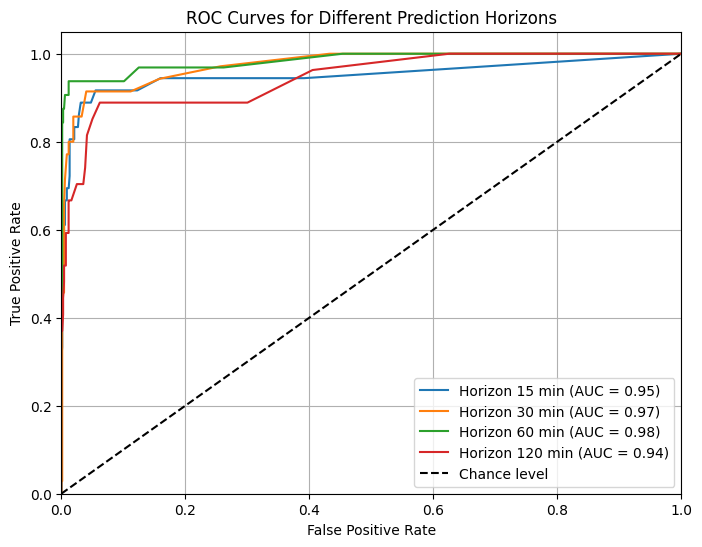

In [11]:

models_2 = {}
y_tests = []
y_probas = []

for horizon in prediction_horizons:

    model = train_hypo(horizon, dfs[horizon])
    models_2[horizon] = model
    
    # Extract test data for this horizon 
    X_test = data_splits[horizon]['X_test']
    y_test = data_splits[horizon]['y_hypo_test']
    
    # Predict probabilities for positive class
    y_proba = model.predict_proba(X_test)[:, 1]

    y_tests.append(y_test)
    y_probas.append(y_proba)


plot_multiple_roc_curves(y_tests, y_probas, horizons=[f"{h} min" for h in prediction_horizons])



Now the explanations and evaluations of them, i already have the true positive, true negatives, false positive, false negatives cases for hyperglycemia and hypoglycemia so i can use those and the explanation output to see how good it is.

NOTE my explanations are built to explain the high probability of  risk episode they are not so adapted to explain the low probability of it

In [12]:
def get_base_name(feat_name):
    prefixes = ["Glucose", "Insulin on board", "COB", "Calories", "Distance", "BPM"]
    for prefix in prefixes:
        if feat_name.startswith(prefix):
            return prefix
    return feat_name


In [ ]:
df_temp = dfs[15]
input_row = df_temp.iloc[[30]]

print(input_row)
explainer = shap.TreeExplainer(models[15])

shap_values = explainer.shap_values(input_row)


highest_shap_0 = []  
highest_shap_1 = []

for i in range(len(input_row.columns)):
    feat_name = input_row.columns[i]
    shap_val = shap_values[0][i]  # [class_0_shap, class_1_shap]

    shap_val_0 = shap_val[0]  # Class 0 SHAP
    shap_val_1 = shap_val[1]  # Class 1 SHAP

    highest_shap_0.append((abs(shap_val_0), shap_val_0, feat_name))
    highest_shap_1.append((abs(shap_val_1), shap_val_1, feat_name))

highest_shap_0.sort(key=lambda x: x[0], reverse=True)
highest_shap_1.sort(key=lambda x: x[0], reverse=True)
def get_base_name(feat_name):
    prefixes = ["Glucose", "Insulin on board", "COB", "Calories", "Distance", "BPM"]
    for prefix in prefixes:
        if feat_name.startswith(prefix):
            return prefix
    return feat_name

def print_top_with_counts(highest_shap, class_label, count_limit=5):
    print(f"Top {count_limit} features for class {class_label} by absolute SHAP value (with counts for repeated base names):")

    seen = {}
    printed = 0
    i = 0
    while printed < count_limit and i < len(highest_shap):
        abs_val, val, feat = highest_shap[i]
        base_name = get_base_name(feat)
        seen[base_name] = seen.get(base_name, 0) + 1
        suffix = f" ({seen[base_name]})" if seen[base_name] > 1 else ""
        print(f"{printed+1}. {feat}{suffix}: SHAP value = {val:.4f}")
        printed += 1
        i += 1

def print_top_distinct_base_names(highest_shap, class_label, distinct_limit=5):
    print(f"\nTop {distinct_limit} distinct base name features for class {class_label} by absolute SHAP value:")

    seen = set()
    printed = 0
    i = 0
    while printed < distinct_limit and i < len(highest_shap):
        abs_val, val, feat = highest_shap[i]
        base_name = get_base_name(feat)
        if base_name not in seen:
            print(f"{printed+1}. {feat}: SHAP value = {val:.4f}")
            seen.add(base_name)
            printed += 1
        i += 1

print_top_with_counts(highest_shap_0, class_label=0)
print_top_distinct_base_names(highest_shap_0, class_label=0)

print("\n")

print_top_with_counts(highest_shap_1, class_label=1)
print_top_distinct_base_names(highest_shap_1, class_label=1)


    Glucose_t-105min  BPM_t-105min  Distance_t-105min  Calories_t-105min  \
30               7.2     79.668824              227.9              75.81   

    Insulin on board_t-105min  COB_t-105min  Glucose_t-90min  BPM_t-90min  \
30                   0.718125      3.777686              7.7    72.318413   

    Distance_t-90min  Calories_t-90min  ...  Insulin on board_t-15min  \
30              19.3             49.33  ...                  1.286377   

    COB_t-15min  Glucose_t-0min  BPM_t-0min  Distance_t-0min  Calories_t-0min  \
30     3.483026            11.9   72.286667              0.0            18.83   

    Insulin on board_t-0min  COB_t-0min  Outcome_Hyperglycemia  \
30                 1.368212    4.078751                      1   

    Outcome_Hypoglycemia  
30                     0  

[1 rows x 50 columns]
Top 5 features for class 0 by absolute SHAP value (with counts for repeated base names):
1. Glucose_t-0min: SHAP value = -0.1387
2. Glucose_t-15min (2): SHAP value = -0.063

Here we add some contextual explanations as decribed in the report, but they should be further refined to protray clinical importance

In [ ]:
def get_top_base_names(highest_shap, limit=5):
    seen = set()
    top_bases = []
    for _, _, feat in highest_shap:
        base = get_base_name(feat)
        if base not in seen:
            top_bases.append(base)
            seen.add(base)
        if len(top_bases) >= limit:
            break
    return top_bases

top_features_0 = get_top_base_names(highest_shap_0)
top_features_1 = get_top_base_names(highest_shap_1)


top_features = list(set(top_features_0 + top_features_1))

# Now add your contextual explanations based on these top features
explanations = []

if "Insulin on board" in top_features and "COB" in top_features:
    explanations.append(
        " If rapid insulin is given, eat carbohydrates to prevent glucose from dropping too low."
    )
if "Insulin on board" in top_features and "Distance" in top_features:
    explanations.append(
        "If exercising after insulin, expect increased insulin sensitivity; consume carbs or reduce insulin to avoid hypoglycemia."
    )
if "Insulin on board" in top_features and "Calories" in top_features:
    explanations.append(
    "If exercising after insulin, expect increased insulin sensitivity; consume carbs or reduce insulin to avoid hypoglycemia."
)
if "Insulin on board" in top_features and "BPM" in top_features:
    explanations.append(
        "If exercising after insulin, expect increased insulin sensitivity; consume carbs or reduce insulin to avoid hypoglycemia."
    )
if "COB" in top_features and "Distance" in top_features:
    explanations.append(
        " If exercising, eat carbs beforehand to maintain glucose and prevent lows. "
    )
if "COB" in top_features and "Calories" in top_features:
    explanations.append(
        " If exercising, eat carbs beforehand to maintain glucose and prevent lows. "
    )
if "COB" in top_features and "BPM" in top_features:
    explanations.append(
        " If exercising, eat carbs beforehand to maintain glucose and prevent lows. "
    )


In [ ]:
def Explainer(df,model):

    df_temp = df
    explainer = shap.TreeExplainer(model)

    def analyze_row_shap(row):

        shap_values = explainer.shap_values(row)

        highest_shap_0 = []
        highest_shap_1 = []

        for i in range(len(row.columns)):
            feat_name = row.columns[i]
            shap_val = shap_values[0][i]  

            shap_val_0 = shap_val[0]
            shap_val_1 = shap_val[1]

            highest_shap_0.append((abs(shap_val_0), shap_val_0, feat_name))
            highest_shap_1.append((abs(shap_val_1), shap_val_1, feat_name))

        highest_shap_0.sort(key=lambda x: x[0], reverse=True)
        highest_shap_1.sort(key=lambda x: x[0], reverse=True)

        print(f"\n--- SHAP analysis for sample index {row.index[0]} ---")

        print_top_with_counts(highest_shap_0, class_label=0)
        print_top_distinct_base_names(highest_shap_0, class_label=0)

        print("\n")

Now we make a method to put a specific time and run the epxlainer this together with the misclassification detection prior is used to do the experiments, to see which case of TP,TN,FP,FN and the explanations obtained for them

In [ ]:
def run_explainer_for_time_and_horizon(dfs, models_hyper, models_hypo, index, prediction_horizon):
    print(f"\n\n===== Horizon: {prediction_horizon} minutes =====")

    df_temp = dfs[prediction_horizon]

    df_filtered = df_temp.iloc[[index]]
    if df_filtered.empty:
        print(f"No rows found for index {index} at horizon {prediction_horizon}")
        return

    print(f"\nRow at index {index}:")
    for col in df_filtered.columns:
        val = df_filtered.iloc[0][col]
        print(f"{col}: {val}")

    X_input = df_filtered.drop(columns=['Outcome_Hyperglycemia', 'Outcome_Hypoglycemia'])

    print("Predicted hyperglycemia probability:")
    y_proba_hyper = models_hyper[prediction_horizon].predict_proba(X_input)[:, 1]
    print(y_proba_hyper)

    print("Actual hyperglycemia outcome:")
    print(df_filtered['Outcome_Hyperglycemia'].values)

    print("Predicted hypoglycemia probability:")
    y_proba_hypo = models_hypo[prediction_horizon].predict_proba(X_input)[:, 1]
    print(y_proba_hypo)

    print("Actual hypoglycemia outcome:")
    print(df_filtered['Outcome_Hypoglycemia'].values)


    
    print(f"\n\n===== Hyperglycemia predictor =====")
    Explainer(df_filtered, models_hyper[prediction_horizon])

    print(f"\n\n===== Hypoglycemia predictor =====")
    Explainer(df_filtered, models_hypo[prediction_horizon])


#CALL
index = 1816 #Update depending on the date we want to inspect, get prediction and explanation
run_explainer_for_time_and_horizon(dfs, models, models_2, index, 30)





===== Horizon: 30 minutes =====

Row at index 1816:
Glucose_t-105min: 7.8
BPM_t-105min: 83.38694638694639
Distance_t-105min: 21.5
Calories_t-105min: 17.64
Insulin on board_t-105min: 18.51100340745221
COB_t-105min: 12.37576596490103
Glucose_t-90min: 8.5
BPM_t-90min: 84.90576719576718
Distance_t-90min: 23.4
Calories_t-90min: 27.58
Insulin on board_t-90min: 18.576653721782307
COB_t-90min: 11.60205982179675
Glucose_t-75min: 8.1
BPM_t-75min: 88.53309523809524
Distance_t-75min: 6.1
Calories_t-75min: 30.61
Insulin on board_t-75min: 18.633782779902106
COB_t-75min: 15.668291197206472
Glucose_t-60min: 7.1
BPM_t-60min: 93.10578162578165
Distance_t-60min: 24.9
Calories_t-60min: 17.36
Insulin on board_t-60min: 18.682679009527533
COB_t-60min: 20.453309378618734
Glucose_t-45min: 6.1
BPM_t-45min: 100.20821548821549
Distance_t-45min: 4.8
Calories_t-45min: 20.9
Insulin on board_t-45min: 18.723623162186584
COB_t-45min: 20.64621047436464
Glucose_t-30min: 5.9
BPM_t-30min: 91.69910533910532
Distance_t-30m